# 01 — Data Exploration

Goal: understand the KASANDR ad-impression data, inspect class imbalance, timestamps, missing values and the main categorical dimensions before modeling.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/raw/train_de.csv")
SAMPLE_ROWS = 250_000

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Download KASANDR from UCI and place train_de.csv in data/raw/."
    )

df = pd.read_csv(DATA_PATH, nrows=SAMPLE_ROWS)
print(df.shape)
df.head()


(250000, 1)


,userid\tofferid\tcountrycode\tcategory\tmerchant\tutcdate\trating
0,fa937b779184527f12e2d71c711e6411236d1ab59f8597...
1,f6c8958b9bc2d6033ff4c1cc0a03e9ab96df4bcc528913...
2,02fe7ccf1de19a387afc8a11d08852ffd2b4dabaed4e2d...
3,9de5c06d0a16256b13b8e7cdc50bf203ecef533eb5cbe1...
4,8d26ade603ea5473c3844aebfcd9e96e6adc8ff411576e...


In [5]:
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))
print("\nTarget distribution:")
target_col = "click" if "click" in df.columns else "rating"
print(df[target_col].value_counts(normalize=True).rename("share"))


userid           str
offerid          str
countrycode      str
category       int64
merchant         str
utcdate          str
rating         int64
dtype: object

Missing values:
userid         0
offerid        0
countrycode    0
category       0
merchant       0
utcdate        0
rating         0
dtype: int64

Target distribution:
rating
0    0.9548
1    0.0452
Name: share, dtype: float64


KeyError: 'Column not found: click'

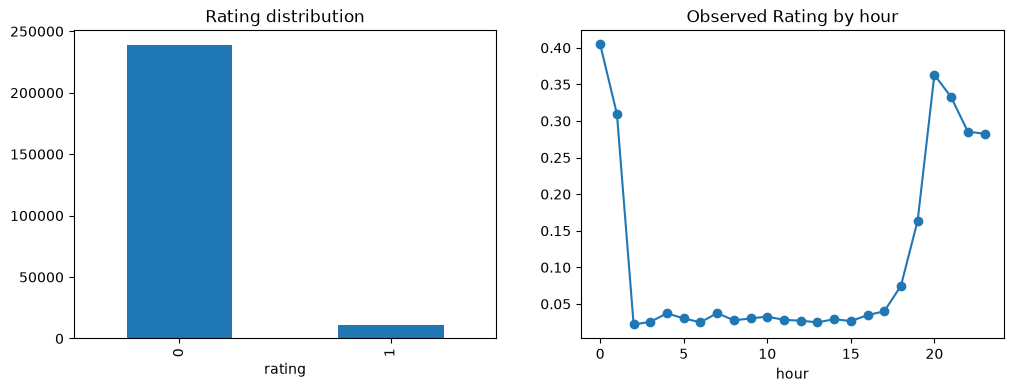

In [7]:
df["utcdate"] = pd.to_datetime(df["utcdate"], errors="coerce")
df["hour"] = df["utcdate"].dt.hour
df["dayofweek"] = df["utcdate"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_col = "click" if "click" in df.columns else "rating"

df[target_col].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title=f"{target_col.title()} distribution"
)
df.groupby("hour")[target_col].mean().plot(
    kind="line", marker="o", ax=axes[1], title=f"Observed {target_col.title()} by hour"
)
df.groupby("hour")["click"].mean().plot(kind="line", marker="o", ax=axes[1], title="Observed CTR by hour")
axes[0].set_xlabel("click")
axes[1].set_ylabel("CTR")
plt.tight_layout()
plt.show()


In [9]:
for col in ["countrycode", "category", "merchant"]:
    target_col = "click" if "click" in df.columns else "rating"
    summary = (
        df.groupby(col)[target_col]
        .agg(impressions="size", clicks="sum", ctr="mean")
        .sort_values("impressions", ascending=False)
        .head(10)
    )
    print(f"\nTop {col} values")
    display(summary)



Top countrycode values


,impressions,clicks,ctr
countrycode,,,
de,250000,11300,0.0452



Top category values


,impressions,clicks,ctr
category,,,
108101,14676,203,0.013832
108301,13418,288,0.021464
100354123,11995,858,0.071530
100020213,10681,894,0.083700
113501,7359,216,0.029352
125801,7260,900,0.123967
100232023,5882,165,0.028052
100567813,5067,152,0.029998
100091613,4931,231,0.046846



Top merchant values


,impressions,clicks,ctr
merchant,,,
ab8863ef55e574c0093451ca02bc1842bd88e0fc32cf6779f5182b074a072d24,9016,550,0.061003
154f65f908a7406826ed6408a156db1bdb82f8f514dffc9c344dfba31ace8520,7640,211,0.027618
7d5fc213708a75c9ac3bc7d2c7437f8bbbf430dec977fd50f3dddeffafd8f08d,7438,46,0.006184
015bb7e2bf96e4f59a4cb8457c7f29f8892c0eea3c1408bc8812e965433395fb,5839,143,0.024490
ac26975cf46eae9898b7d906bdfbbf99ce7813ffc3f9b7c42163a55e02e81516,5011,832,0.166035
81dc9575e12600c50cca637701215bdf3d923eebcb08cc4c67fd928103c4931a,4878,131,0.026855
8fb1fab99fe590d1020a4f2868922d2e0009b933c0126093240eb28cc176bbab,4677,87,0.018602
fca91704667a53350611d159de21c2e5de8eeab874e4041e4c8bbe1edae0e64e,4596,220,0.047868
ff1bd73f19ccc09842c0b0ad14ff0402e91324cdf924aa3a6a39bfd8c2d9acb3,4415,151,0.034202


## Initial observations

- CTR is a rare-event classification target, so accuracy should not be the main metric.
- Time features are likely to capture user activity patterns.
- `userid` and `offerid` are high-cardinality identifiers; treating them as raw numeric values would be misleading.
- The next notebook creates time features and prepares categorical fields for a tree-based model.
